In [1]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost shap openpyxl joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import xgboost as xgb
import shap
import joblib

# Для отображения графиков в ноутбуке
%matplotlib inline
plt.style.use('ggplot')

print("Библиотеки загружены")

Библиотеки загружены


In [3]:
def load_incidents(file_path):
    df = pd.read_excel(file_path, sheet_name='Sheet1')
    df.columns = df.columns.str.strip().str.replace(' ', '_')
    df['Дата_инцидента'] = pd.to_datetime(df['Дата_инцидента'], dayfirst=True)
    df['Региональное_время'] = pd.to_datetime(df['Региональное_время'], dayfirst=True)
    df['час'] = df['Региональное_время'].dt.hour
    df['день_недели'] = df['Региональное_время'].dt.dayofweek
    df['месяц'] = df['Региональное_время'].dt.month
    
    def get_season(month):
        if month in [12, 1, 2]:
            return 'зима'
        elif month in [3, 4, 5]:
            return 'весна'
        elif month in [6, 7, 8]:
            return 'лето'
        else:
            return 'осень'
    df['сезон'] = df['месяц'].apply(get_season)
    return df


In [4]:
def load_threats(file_path):
    df = pd.read_excel(file_path, sheet_name='Sheet', header=1)
    df = df[['Идентификатор УБИ', 'Наименование УБИ']].copy()
    df['Идентификатор_целое'] = df['Идентификатор УБИ'].astype(str).str.split('.').str[0].astype(int)
    df = df.rename(columns={'Идентификатор_целое': 'Код_угрозы', 'Наименование УБИ': 'Название_угрозы'})
    return df

In [5]:
def merge_data(incidents, threats):
    df = incidents.merge(threats, left_on='Код_реализованной_угрозы', right_on='Код_угрозы', how='left')
    return df

print("Функции загрузки определены")

Функции загрузки определены


In [6]:
# Укажите корректные пути к файлам
incidents_df = load_incidents('incidents_2000.xlsx')
threats_df = load_threats('Файл с сайта ФСТЭК.xlsx')
df = merge_data(incidents_df, threats_df)

print("=== Общая статистика ===")
print(f"Всего инцидентов: {len(df)}")
print(f"Успешных атак: {df['Успех'].sum()}")
print(f"Процент успешных: {df['Успех'].mean()*100:.2f}%")

=== Общая статистика ===
Всего инцидентов: 2000
Успешных атак: 1005
Процент успешных: 50.25%


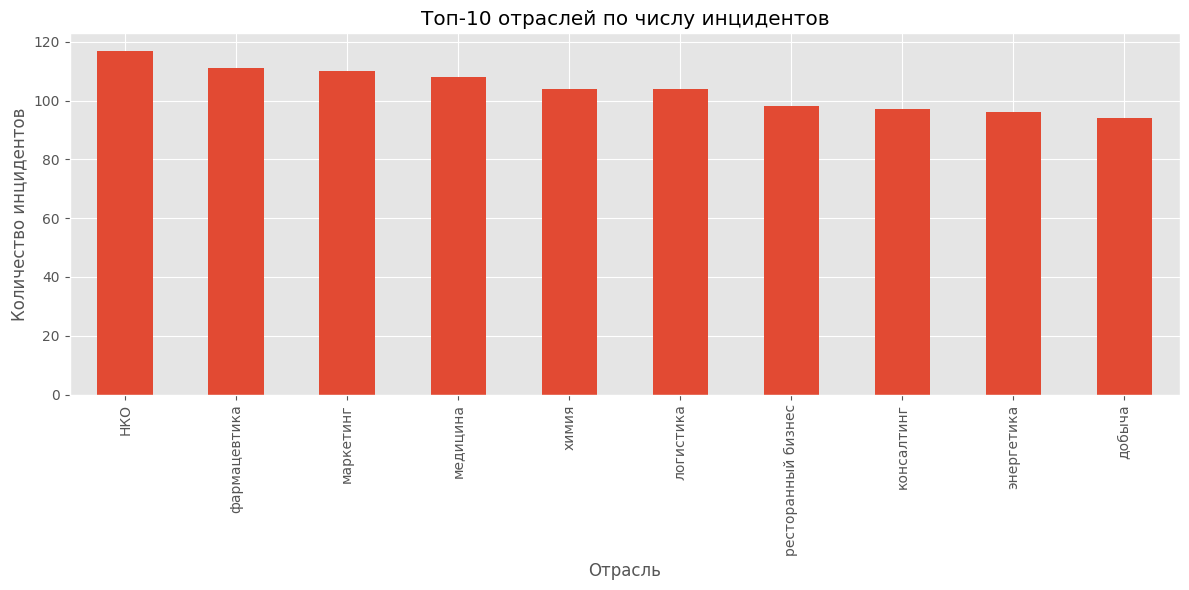

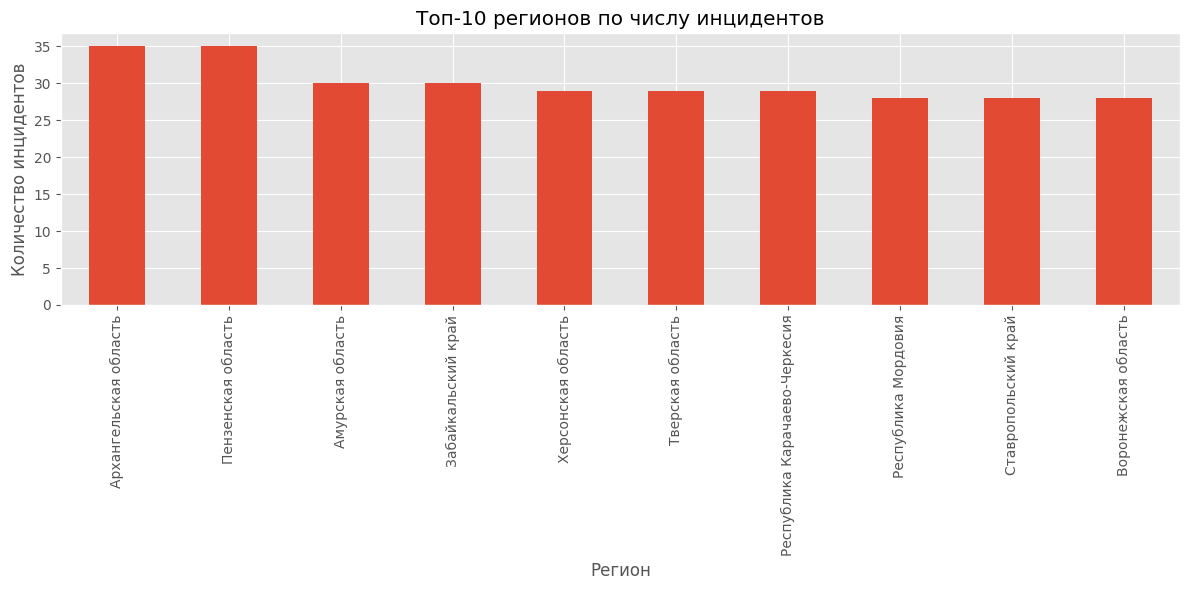

In [7]:
# Отрасли
plt.figure(figsize=(12,6))
top_industries = df['Тип_предприятия'].value_counts().head(10)
top_industries.plot(kind='bar')
plt.title('Топ-10 отраслей по числу инцидентов')
plt.xlabel('Отрасль')
plt.ylabel('Количество инцидентов')
plt.tight_layout()
plt.savefig('fig_industries.png')
plt.show()

# Регионы
plt.figure(figsize=(12,6))
top_regions = df['Регион_размещения_предприятия'].value_counts().head(10)
top_regions.plot(kind='bar')
plt.title('Топ-10 регионов по числу инцидентов')
plt.xlabel('Регион')
plt.ylabel('Количество инцидентов')
plt.tight_layout()
plt.savefig('fig_regions.png')
plt.show()

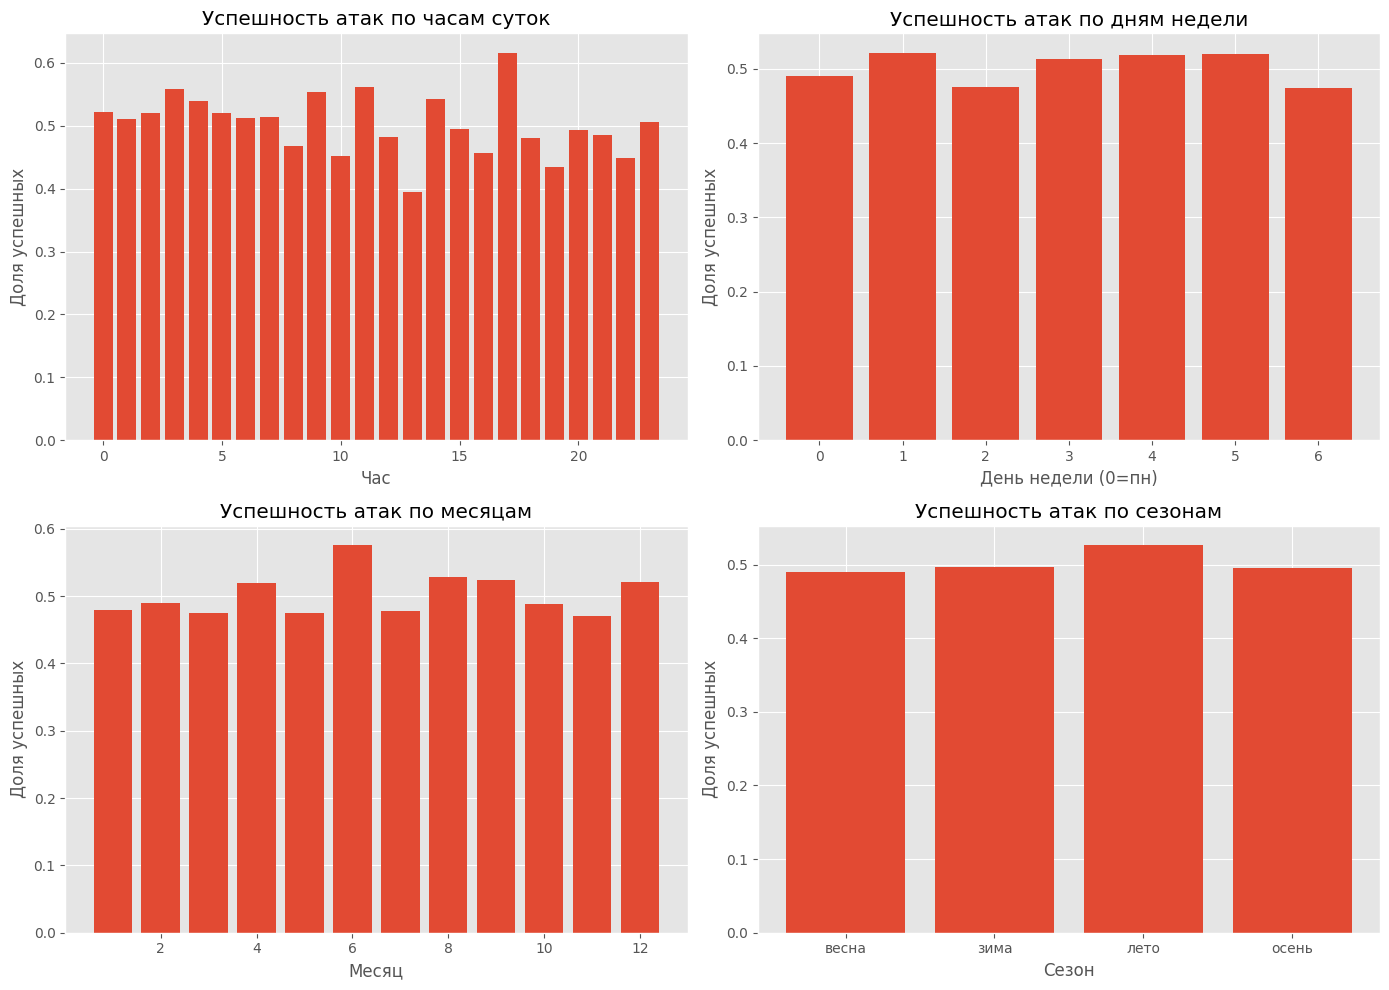


=== Временные паттерны ===
Пиковые часы успешности: 17:00 с долей 0.62
Наиболее опасный день недели (0=пн): 1
Наиболее опасный месяц: 6
Наиболее опасный сезон: лето


In [8]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

hour_success = df.groupby('час')['Успех'].mean()
axes[0,0].bar(hour_success.index, hour_success.values)
axes[0,0].set_title('Успешность атак по часам суток')
axes[0,0].set_xlabel('Час')
axes[0,0].set_ylabel('Доля успешных')

dow_success = df.groupby('день_недели')['Успех'].mean()
axes[0,1].bar(dow_success.index, dow_success.values)
axes[0,1].set_title('Успешность атак по дням недели')
axes[0,1].set_xlabel('День недели (0=пн)')
axes[0,1].set_ylabel('Доля успешных')

month_success = df.groupby('месяц')['Успех'].mean()
axes[1,0].bar(month_success.index, month_success.values)
axes[1,0].set_title('Успешность атак по месяцам')
axes[1,0].set_xlabel('Месяц')
axes[1,0].set_ylabel('Доля успешных')

season_success = df.groupby('сезон')['Успех'].mean()
axes[1,1].bar(season_success.index, season_success.values)
axes[1,1].set_title('Успешность атак по сезонам')
axes[1,1].set_xlabel('Сезон')
axes[1,1].set_ylabel('Доля успешных')

plt.tight_layout()
plt.savefig('fig_temporal_patterns.png')
plt.show()

print("\n=== Временные паттерны ===")
print(f"Пиковые часы успешности: {hour_success.idxmax()}:00 с долей {hour_success.max():.2f}")
print(f"Наиболее опасный день недели (0=пн): {dow_success.idxmax()}")
print(f"Наиболее опасный месяц: {month_success.idxmax()}")
print(f"Наиболее опасный сезон: {season_success.idxmax()}")

In [9]:
# Выбираем признаки для кластеризации
cat_cols = ['Тип_предприятия', 'Регион_размещения_предприятия', 'сезон']
num_cols = ['Количество_хостов', 'час', 'день_недели', 'месяц']

# Кодируем категориальные переменные
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Признаки для кластеризации
cluster_features = num_cols + [col + '_enc' for col in cat_cols]
X_cluster = df[cluster_features].copy()

# Стандартизация
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Признаки подготовлены, размер:", X_cluster_scaled.shape)

Признаки подготовлены, размер: (2000, 7)


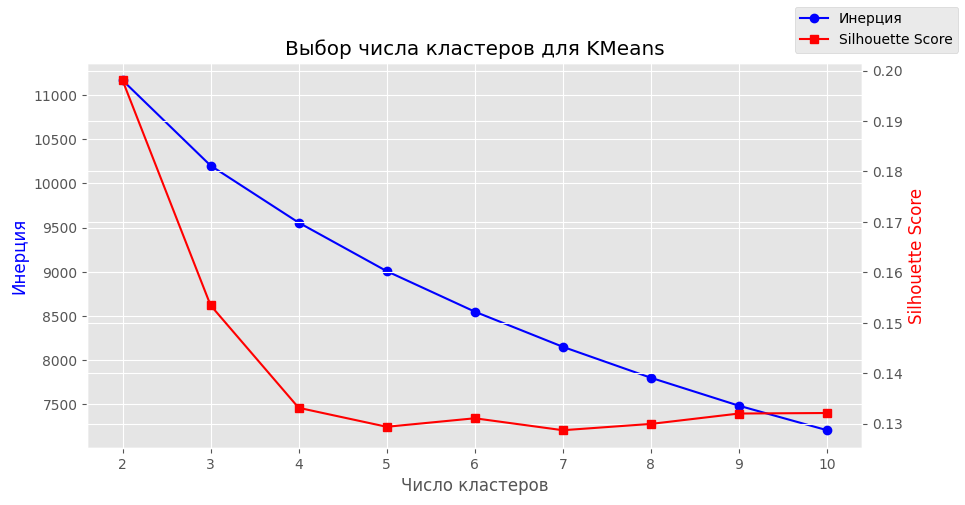

Оптимальное число кластеров по силуэту: 2


In [10]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    labels = kmeans.labels_
    sil = silhouette_score(X_cluster_scaled, labels)
    silhouettes.append(sil)

# График локтя и силуэта
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(K_range, inertias, 'bo-', label='Инерция')
ax1.set_xlabel('Число кластеров')
ax1.set_ylabel('Инерция', color='b')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Выбор числа кластеров для KMeans')
fig.legend(loc='upper right')
plt.savefig('fig_cluster_elbow.png')
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Оптимальное число кластеров по силуэту: {best_k}")

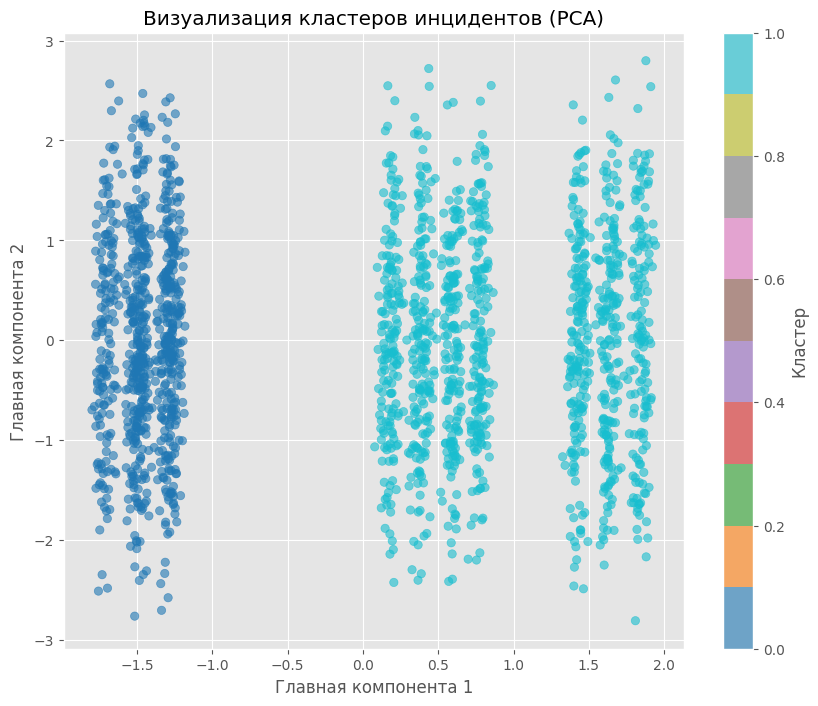


Профили кластеров (средние значения):
         Количество_хостов        час  день_недели     месяц     Успех  count
cluster                                                                      
0              1080.931421  11.236908     3.021197  2.971322  0.487531    802
1              1093.315526  11.429048     3.001669  8.973289  0.512521   1198


In [11]:
from sklearn.decomposition import PCA

# Обучаем KMeans с лучшим k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# PCA для 2D визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

plt.figure(figsize=(10,8))
scatter = plt.scatter(df['pca1'], df['pca2'], c=df['cluster'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Кластер')
plt.title('Визуализация кластеров инцидентов (PCA)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.savefig('fig_clusters_pca.png')
plt.show()

# Профили кластеров
cluster_profile = df.groupby('cluster')[num_cols + ['Успех']].mean()
cluster_profile['count'] = df['cluster'].value_counts()
print("\nПрофили кластеров (средние значения):")
print(cluster_profile)

In [12]:
# Базовые признаки (без кластеров)
feature_cols_base = num_cols + [col + '_enc' for col in cat_cols]
X_base = df[feature_cols_base].copy()

# Расширенные признаки (с кластером)
feature_cols_ext = feature_cols_base + ['cluster']
X_ext = df[feature_cols_ext].copy()

# Целевые переменные
y_success = df['Успех'].values
y_threat = df['Код_реализованной_угрозы'].values

# Стандартизация числовых признаков
scaler = StandardScaler()
X_base[num_cols] = scaler.fit_transform(X_base[num_cols])
X_ext[num_cols] = X_base[num_cols]  # уже масштабированы

print("Признаки для моделирования готовы")

Признаки для моделирования готовы


In [13]:
# Разделение данных (стратификация по успеху)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_success, test_size=0.2, random_state=42, stratify=y_success
)
X_train_e, X_test_e, _, _ = train_test_split(
    X_ext, y_success, test_size=0.2, random_state=42, stratify=y_success
)

# Baseline модель
model_baseline = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)
model_baseline.fit(X_train_b, y_train_b)
y_pred_b = model_baseline.predict(X_test_b)
acc_b = accuracy_score(y_test_b, y_pred_b)

# Улучшенная модель
model_improved = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='logloss'
)
model_improved.fit(X_train_e, y_train_b)
y_pred_e = model_improved.predict(X_test_e)
acc_e = accuracy_score(y_test_b, y_pred_e)

print("=== Сравнение моделей предсказания успешности атаки ===")
print(f"Точность baseline (без кластеров): {acc_b:.4f}")
print(f"Точность improved (с кластерами): {acc_e:.4f}")
print(f"Улучшение на {acc_e - acc_b:.4f}")
print("\nClassification report (improved model):")
print(classification_report(y_test_b, y_pred_e))

=== Сравнение моделей предсказания успешности атаки ===
Точность baseline (без кластеров): 0.4975
Точность improved (с кластерами): 0.4975
Улучшение на 0.0000

Classification report (improved model):
              precision    recall  f1-score   support

           0       0.49      0.50      0.50       199
           1       0.50      0.50      0.50       201

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400



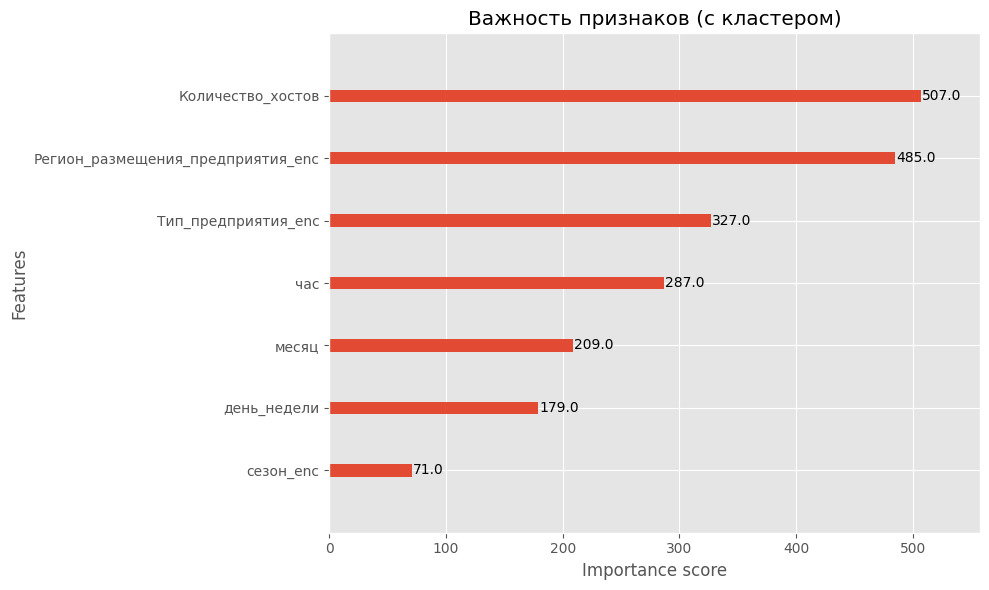

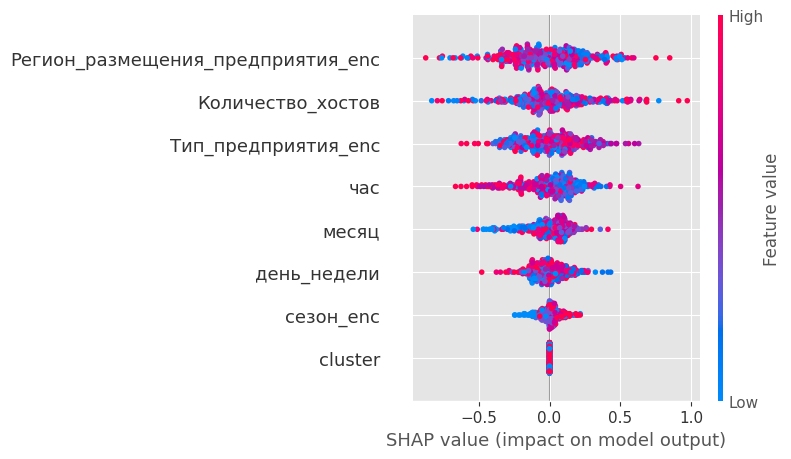

In [14]:
# Важность признаков
plt.figure(figsize=(10,6))
xgb.plot_importance(model_improved, importance_type='weight', ax=plt.gca(), 
                    title='Важность признаков (с кластером)')
plt.tight_layout()
plt.savefig('fig_feature_importance_improved.png')
plt.show()

# SHAP анализ (может выполняться долго, можно пропустить при необходимости)
explainer = shap.TreeExplainer(model_improved)
shap_values = explainer.shap_values(X_test_e)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_e, feature_names=feature_cols_ext, show=False)
plt.tight_layout()
plt.savefig('fig_shap_summary_improved.png')
plt.show()

In [15]:
# Ограничимся топ-10 угроз по частоте
top_threats = df['Код_реализованной_угрозы'].value_counts().head(10).index
df_threat_subset = df[df['Код_реализованной_угрозы'].isin(top_threats)].copy()

X_threat_base = df_threat_subset[feature_cols_base].copy()
X_threat_ext = df_threat_subset[feature_cols_ext].copy()
y_threat_subset = df_threat_subset['Код_реализованной_угрозы'].values

# Масштабирование
X_threat_base[num_cols] = scaler.transform(X_threat_base[num_cols])
X_threat_ext[num_cols] = scaler.transform(X_threat_ext[num_cols])

le_threat = LabelEncoder()
y_threat_enc = le_threat.fit_transform(y_threat_subset)

# Разделение данных
X_train_tb, X_test_tb, y_train_tb, y_test_tb = train_test_split(
    X_threat_base, y_threat_enc, test_size=0.2, random_state=42, stratify=y_threat_enc
)
X_train_te, X_test_te, _, _ = train_test_split(
    X_threat_ext, y_threat_enc, test_size=0.2, random_state=42, stratify=y_threat_enc
)

# Baseline модель
model_threat_b = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='mlogloss'
)
model_threat_b.fit(X_train_tb, y_train_tb)
acc_threat_b = accuracy_score(y_test_tb, model_threat_b.predict(X_test_tb))

# Improved модель
model_threat_e = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, use_label_encoder=False, eval_metric='mlogloss'
)
model_threat_e.fit(X_train_te, y_train_tb)
acc_threat_e = accuracy_score(y_test_tb, model_threat_e.predict(X_test_te))

print("=== Сравнение моделей предсказания типа угрозы (топ-10) ===")
print(f"Точность baseline (без кластеров): {acc_threat_b:.4f}")
print(f"Точность improved (с кластерами): {acc_threat_e:.4f}")
print(f"Улучшение на {acc_threat_e - acc_threat_b:.4f}")
print("\nClassification report (improved threat model):")
print(classification_report(y_test_tb, model_threat_e.predict(X_test_te), 
                            target_names=le_threat.classes_.astype(str)))

=== Сравнение моделей предсказания типа угрозы (топ-10) ===
Точность baseline (без кластеров): 0.0667
Точность improved (с кластерами): 0.0667
Улучшение на 0.0000

Classification report (improved threat model):
              precision    recall  f1-score   support

          16       0.00      0.00      0.00         3
          18       0.00      0.00      0.00         3
          26       0.00      0.00      0.00         3
          39       0.00      0.00      0.00         3
          40       0.33      0.33      0.33         3
          41       0.17      0.33      0.22         3
          67       0.00      0.00      0.00         3
          73       0.00      0.00      0.00         3
         161       0.00      0.00      0.00         3
         191       0.00      0.00      0.00         3

    accuracy                           0.07        30
   macro avg       0.05      0.07      0.06        30
weighted avg       0.05      0.07      0.06        30



In [16]:
print("=== Анализ уязвимых мест ===\n")

industry_success = df.groupby('Тип_предприятия')['Успех'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Топ-5 отраслей с наибольшей долей успешных атак:")
print(industry_success.head(5), "\n")

region_success = df.groupby('Регион_размещения_предприятия')['Успех'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Топ-5 регионов с наибольшей долей успешных атак:")
print(region_success.head(5), "\n")

threat_success = df.groupby('Название_угрозы')['Успех'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Угрозы с наибольшей долей успеха (min 10 инцидентов):")
threat_success_filtered = threat_success[threat_success['count'] >= 10].head(10)
print(threat_success_filtered, "\n")

cluster_risk = df.groupby('cluster')['Успех'].mean().sort_values(ascending=False)
print("Риск по кластерам (доля успешных атак):")
print(cluster_risk)

=== Анализ уязвимых мест ===

Топ-5 отраслей с наибольшей долей успешных атак:
                        mean  count
Тип_предприятия                    
металлургия         0.607595     79
образование         0.563830     94
отели               0.555556     90
телекоммуникации    0.550562     89
ресторанный бизнес  0.540816     98 

Топ-5 регионов с наибольшей долей успешных атак:
                                   mean  count
Регион_размещения_предприятия                 
Республика Татарстан           0.750000     24
Республика Калмыкия            0.733333     15
Красноярский край              0.727273     11
Сахалинская область            0.722222     18
Камчатский край                0.678571     28 

Угрозы с наибольшей долей успеха (min 10 инцидентов):
                                                        mean  count
Название_угрозы                                                    
Угроза несвоевременного выявления и реагировани...  0.800000     10
Угроза подмены резервной копи